# 📊 Marketing Campaign A/B/C Testing
**Objective:** Determine which of our three marketing promotions drives the highest statistically significant sales volume.

**Methodology:** Because we have more than two groups and want to avoid strict parametric assumptions, we will use a **Kruskal-Wallis H-test** to check for overall significance, followed by pairwise **Mann-Whitney U tests** (with Bonferroni correction) to find the specific winner.

In [9]:
# Force Jupyter to reload external files automatically
%load_ext autoreload
%autoreload 2

import numpy as np
import scipy.stats as stats
import statsmodels.formula.api as smf
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Import our custom stats module from the src folder
from src import stats_utils

# Make our plots look nice
sns.set_theme(style="whitegrid")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### 1. Data Loading & High-Level Overview
First, we load the raw market data to ensure everything is structured correctly before we run our statistical tests.


In [10]:
df = pd.read_csv(r'data\raw_marketing_data.csv')

df.head()


,MarketID,MarketSize,LocationID,AgeOfStore,Promotion,week,SalesInThousands
0,1,Medium,1,4,3,1,33.73
1,1,Medium,1,4,3,2,35.67
2,1,Medium,1,4,3,3,29.03
3,1,Medium,1,4,3,4,39.25
4,1,Medium,2,5,2,1,27.81


### 2. Overall Campaign Performance (Kruskal-Wallis Test)
Let's visually inspect the sales distribution across the three promotions and run our primary statistical test to see if a significant difference actually exists.

     KRUSKAL-WALLIS H-TEST RESULTS       
Statistic : 53.2948
P-value   : 2.6742e-12

✅ Result: Statistically significant difference exists between groups.


C:\Users\Admin\AppData\Local\Temp\ipykernel_1176\3706431772.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


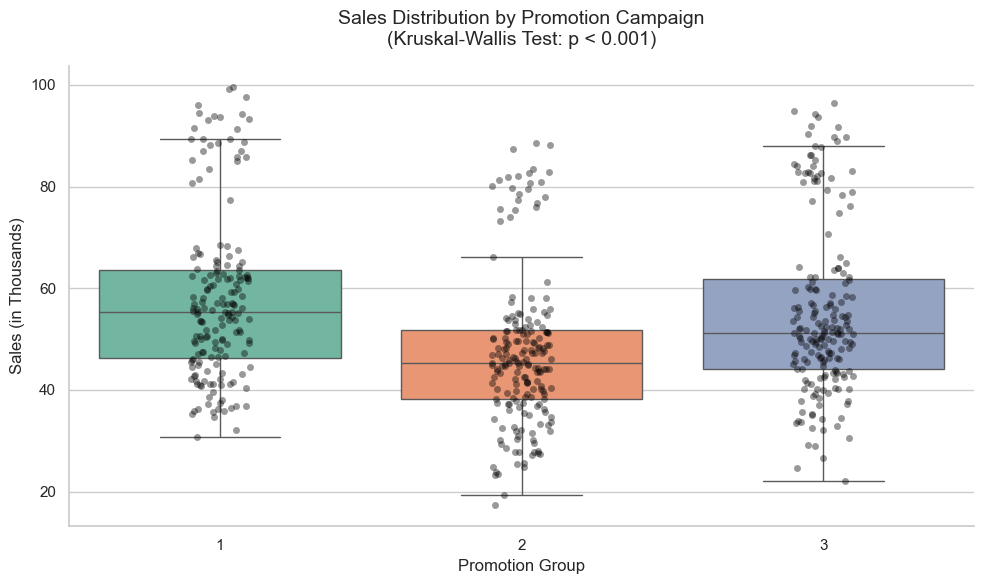

In [11]:
# Run the math using our custom backend function
is_significant, p_val, kw_stat = stats_utils.run_kruskal_wallis(
    df, 
    group_col='Promotion', 
    metric_col='SalesInThousands'
)

# Format the p-value for the chart title
p_val_text = "p < 0.001" if p_val < 0.001 else f"p = {p_val:.4f}"
title_text = f"Sales Distribution by Promotion Campaign\n(Kruskal-Wallis Test: {p_val_text})"

# Create the visual
plt.figure(figsize=(10, 6))

ax = sns.boxplot(
    data=df, x='Promotion', y='SalesInThousands', 
    palette='Set2', showfliers=False 
)

sns.stripplot(
    data=df, x='Promotion', y='SalesInThousands', 
    color='black', alpha=0.4, jitter=True
)

plt.title(title_text, fontsize=14, pad=15)
plt.ylabel('Sales (in Thousands)', fontsize=12)
plt.xlabel('Promotion Group', fontsize=12)

sns.despine()
plt.tight_layout()
plt.show()

### 3. Visualizing the Statistical Proof
To prove *why* the p-value above is significant, we plot our exact test statistic onto the Expected Chi-Square Distribution curve.

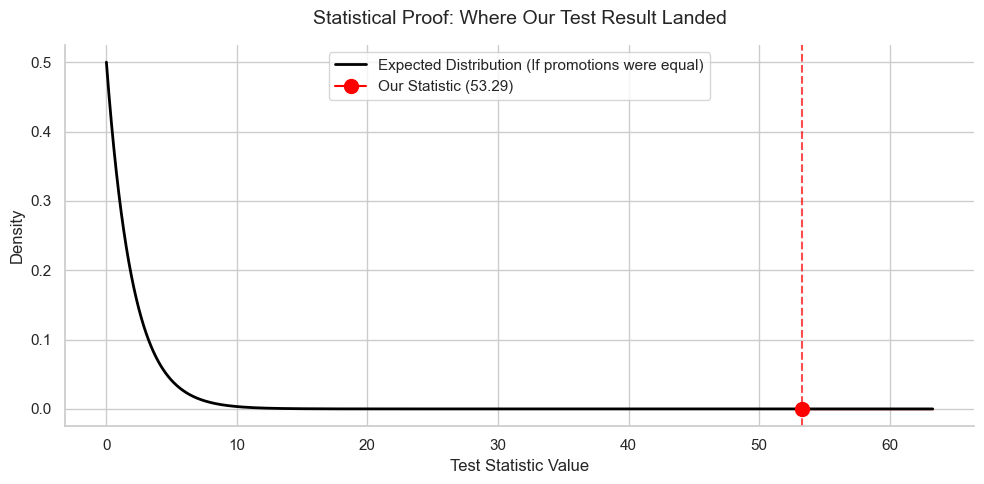

In [12]:
if is_significant:
    # Degrees of freedom for Kruskal-Wallis = (Number of groups) - 1
    df_kw = len(df['Promotion'].unique()) - 1

    # Create the x and y axes for the Chi-Square Distribution
    x = np.linspace(0, kw_stat + 10, 1000)
    y = stats.chi2.pdf(x, df_kw)

    plt.figure(figsize=(10, 5))
    plt.plot(x, y, color='black', lw=2, label='Expected Distribution (If promotions were equal)')

    # Plot our actual test statistic 
    plt.axvline(kw_stat, color='red', linestyle='--', alpha=0.7)
    plt.plot(kw_stat, 0, marker='o', markersize=10, color='red', label=f'Our Statistic ({kw_stat:.2f})')

    plt.fill_between(x[x >= kw_stat], y[x >= kw_stat], color='red', alpha=0.5)

    plt.title('Statistical Proof: Where Our Test Result Landed', fontsize=14, pad=15)
    plt.xlabel('Test Statistic Value', fontsize=12)
    plt.ylabel('Density', fontsize=12)
    plt.legend()
    
    sns.despine()
    plt.tight_layout()
    plt.show()
else:
    print("Test was not significant; no curve to plot.")

### 4. Head-to-Head Matchups (Post-Hoc Analysis)
Since there is a significant difference overall, we now test every promotion against each other (1v2, 1v3, 2v3) to isolate exactly which campaign is driving the most revenue. *Note: We apply a Bonferroni correction to prevent false positives.*

C:\Users\Admin\AppData\Local\Temp\ipykernel_1176\67653965.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


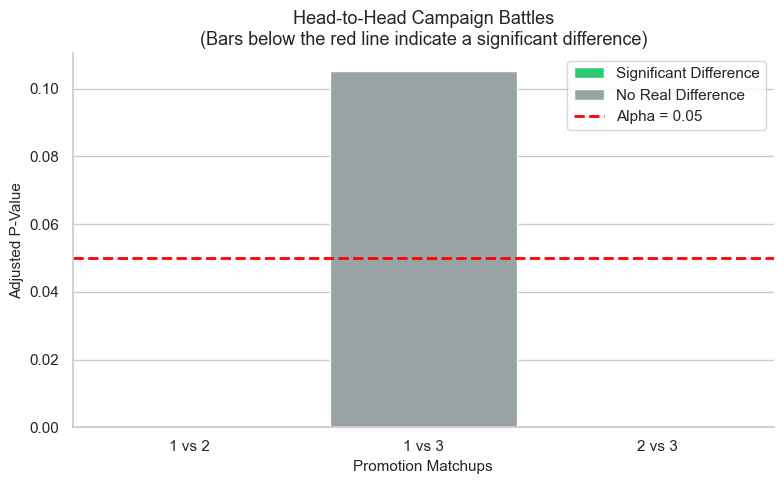

,Comparison,Winner (by Median)
0,1 vs 2,Promotion 1
1,1 vs 3,Tie
2,2 vs 3,Promotion 3


In [13]:
if is_significant:
    results_df = stats_utils.run_posthoc_mannwhitney(
        df, group_col='Promotion', metric_col='SalesInThousands'
    )
    
    colors = ['#2ecc71' if p < 0.05 else '#95a5a6' for p in results_df['Adjusted P-Value']]
    
    plt.figure(figsize=(8, 5))
    ax = sns.barplot(
        data=results_df, x='Comparison', y='Adjusted P-Value', palette=colors
    )
    
    plt.axhline(0.05, color='red', linestyle='--', lw=2, label='Significance Threshold (0.05)')
    
    plt.title('Head-to-Head Campaign Battles\n(Bars below the red line indicate a significant difference)', fontsize=13)
    plt.ylabel('Adjusted P-Value', fontsize=11)
    plt.xlabel('Promotion Matchups', fontsize=11)
    
    legend_elements = [
        Patch(facecolor='#2ecc71', label='Significant Difference'),
        Patch(facecolor='#95a5a6', label='No Real Difference'),
        plt.Line2D([0], [0], color='red', lw=2, linestyle='--', label='Alpha = 0.05')
    ]
    plt.legend(handles=legend_elements, loc='upper right')
    
    sns.despine()
    plt.tight_layout()
    plt.show()
    
    display(results_df[['Comparison', 'Winner (by Median)']])

---
## Phase 2: Deep Dive & Stratification
Our initial test looked at the macro-level, but we have a hidden data flaw: pseudo-replication. Because we have 4 weeks of data for the *same* store, our rows are not independent. 

First, we must aggregate the data so that 1 Store = 1 Row (Total 4-Week Sales). Then, we will stratify our tests to see if the overall "Tie" holds true across different market sizes.

In [14]:
# Aggregate data: Sum the sales across the 4 weeks for each specific store
store_df = df.groupby(
    ['LocationID', 'MarketSize', 'AgeOfStore', 'Promotion']
)['SalesInThousands'].sum().reset_index()

# Rename for absolute clarity
store_df.rename(columns={'SalesInThousands': 'TotalSales_4Weeks'}, inplace=True)

print(f"Original rows (weekly data): {len(df)}")
print(f"Aggregated rows (independent, store-level data): {len(store_df)}")

Original rows (weekly data): 548
Aggregated rows (independent, store-level data): 137


### Segmenting by Market Size
Instead of one giant test, we will slice the dataset into Small, Medium, and Large markets. We will run our Kruskal-Wallis and Mann-Whitney tests *inside* each specific segment to find out if certain promotions dominate specific markets.

In [15]:
# Loop through each market size to run the stats test independently
market_sizes = ['Small', 'Medium', 'Large']

for size in market_sizes:
    print(f"\n\n{'='*50}")
    print(f"ANALYZING MARKET SIZE: {size.upper()}")
    print(f"{'='*50}")
    
    # Slice the data to ONLY include this specific market size
    subset = store_df[store_df['MarketSize'] == size]
    
    # Run the Kruskal-Wallis test on this subset
    is_sig, p_val, kw_stat = stats_utils.run_kruskal_wallis(
        subset, 
        group_col='Promotion', 
        metric_col='TotalSales_4Weeks'
    )
    
    # If it's significant, immediately run the post-hoc test to find the winner
    if is_sig:
        print(f"\nFinding the winner for {size} markets...")
        posthoc_results = stats_utils.run_posthoc_mannwhitney(
            subset, 
            group_col='Promotion', 
            metric_col='TotalSales_4Weeks'
        )
        display(posthoc_results[['Comparison', 'Adjusted P-Value', 'Winner (by Median)']])
    else:
        print(f"\nAll promotions performed equally in {size} markets. No clear winner.")



ANALYZING MARKET SIZE: SMALL
     KRUSKAL-WALLIS H-TEST RESULTS       
Statistic : 6.8333
P-value   : 3.2822e-02

✅ Result: Statistically significant difference exists between groups.

Finding the winner for Small markets...


,Comparison,Adjusted P-Value,Winner (by Median)
0,1 vs 2,0.047619,Promotion 1
1,1 vs 3,1.000000,Tie
2,2 vs 3,0.114286,Tie




ANALYZING MARKET SIZE: MEDIUM
     KRUSKAL-WALLIS H-TEST RESULTS       
Statistic : 15.6347
P-value   : 4.0269e-04

✅ Result: Statistically significant difference exists between groups.

Finding the winner for Medium markets...


,Comparison,Adjusted P-Value,Winner (by Median)
0,1 vs 2,0.001603,Promotion 1
1,1 vs 3,0.725533,Tie
2,2 vs 3,0.004658,Promotion 3




ANALYZING MARKET SIZE: LARGE
     KRUSKAL-WALLIS H-TEST RESULTS       
Statistic : 13.8013
P-value   : 1.0071e-03

✅ Result: Statistically significant difference exists between groups.

Finding the winner for Large markets...


,Comparison,Adjusted P-Value,Winner (by Median)
0,1 vs 2,0.011588,Promotion 1
1,1 vs 3,1.000000,Tie
2,2 vs 3,0.002290,Promotion 3


### Store Age Check (Spearman Rank Correlation)
`AgeOfStore` is a continuous number, not a category, so we cannot use a Kruskal-Wallis test. To ensure age isn't skewing our data, we will run a **Spearman Rank Correlation** to see if older stores naturally sell more, regardless of the marketing campaign.

      SPEARMAN CORRELATION RESULTS       
Correlation Coefficient : -0.0680
P-value                 : 4.2970e-01
Result: Store Age has NO significant impact on Sales.


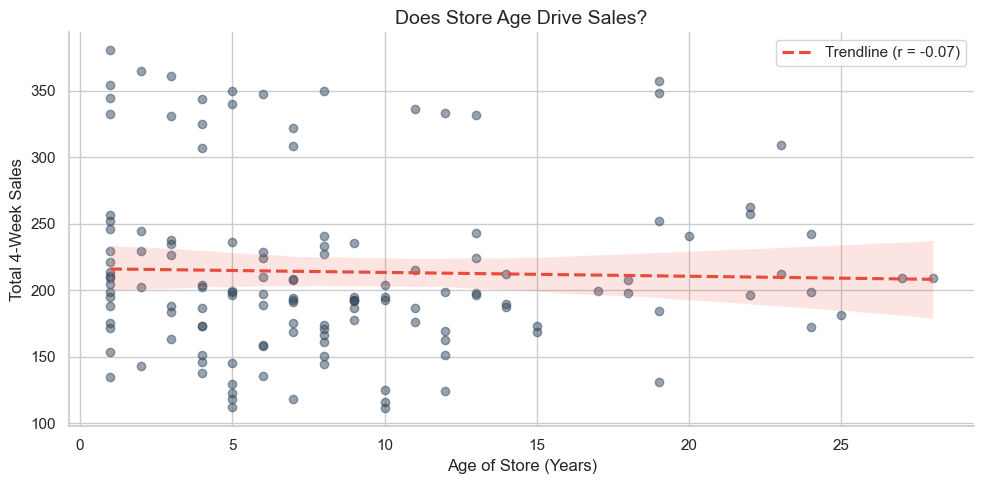

In [16]:
# Calculate Spearman Rank Correlation (non-parametric correlation)
corr, p_value = stats.spearmanr(store_df['AgeOfStore'], store_df['TotalSales_4Weeks'])

print("=========================================")
print("      SPEARMAN CORRELATION RESULTS       ")
print("=========================================")
print(f"Correlation Coefficient : {corr:.4f}")
print(f"P-value                 : {p_value:.4e}")

if p_value < 0.05:
    print("Result: Store Age significantly affects Sales.")
else:
    print("Result: Store Age has NO significant impact on Sales.")

# Visualize the lack of correlation
plt.figure(figsize=(10, 5))
sns.regplot(
    data=store_df, 
    x='AgeOfStore', 
    y='TotalSales_4Weeks',
    scatter_kws={'alpha': 0.5, 'color': '#34495e'},
    line_kws={'color': '#e74c3c', 'linestyle': '--', 'label': f'Trendline (r = {corr:.2f})'}
)

plt.title('Does Store Age Drive Sales?', fontsize=14)
plt.ylabel('Total 4-Week Sales', fontsize=12)
plt.xlabel('Age of Store (Years)', fontsize=12)
plt.legend()
sns.despine()
plt.tight_layout()
plt.show()

## Phase 3: Multivariate Modeling (Multiple Linear Regression)
Our stratified tests in Phase 2 showed a fascinating nuance: Promotion 2 is highly effective in Small markets, but terrible in Large markets. 

To formalize this mathematically and account for all variables simultaneously, we will build an Ordinary Least Squares (OLS) Regression model. We will include an **Interaction Term** (`Promotion * MarketSize`) so the model understands that campaigns behave differently depending on the market they are deployed in.

In [17]:
# Build the regression formula with an interaction term
formula = "TotalSales_4Weeks ~ C(Promotion) * C(MarketSize) + AgeOfStore"

# Fit the Ordinary Least Squares (OLS) model
model = smf.ols(formula=formula, data=store_df)
results = model.fit()

# Display the master statistical report
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:      TotalSales_4Weeks   R-squared:                       0.642
Model:                            OLS   Adj. R-squared:                  0.617
Method:                 Least Squares   F-statistic:                     25.34
Date:                Wed, 27 May 2026   Prob (F-statistic):           1.92e-24
Time:                        11:55:01   Log-Likelihood:                -694.89
No. Observations:                 137   AIC:                             1410.
Df Residuals:                     127   BIC:                             1439.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                                                coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------

### Final Business Recommendation
1. **The Core Winner:** **Promotion 3** is the optimal choice for a nationwide rollout. It dominates our most lucrative segment (Large Markets) and remains highly competitive in Small Markets. It is our safest, highest-yielding baseline.
2. **The Niche Play:** If the marketing team has the bandwidth to run a segmented campaign, **Promotion 2** should be deployed *exclusively* in Small Markets, where it significantly overperforms.
3. **Age is Just a Number:** The regression P-value for `AgeOfStore` confirms that a store's age has zero statistical impact on the success of these marketing campaigns.